# Customer Churn Prediction and Business Analytics Using Machine Learning

## Final Data Science Capstone Project

### Objective
To analyze customer behavior, identify key factors associated with customer churn,
build machine learning models to predict customer churn, and provide actionable
business recommendations for customer retention.

**Dataset:** Telco Customer Churn Dataset

**Tools & Technologies:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## 1. Business Problem

Customer churn is a major challenge for subscription-based businesses.
When customers discontinue their services, the company loses recurring revenue
and may also incur additional costs to acquire new customers.

The objective of this project is to analyze customer demographic, service,
contract, tenure, and billing information to understand customer churn behavior.

The project will also develop machine learning models that can identify
customers who are likely to churn.

### Key Business Questions

1. What percentage of customers are churning?
2. Which customer characteristics are associated with churn?
3. Does contract type affect customer churn?
4. Does customer tenure influence churn?
5. How do monthly charges relate to churn?
6. Which services are associated with higher churn?
7. Which machine learning model performs best?
8. How can the company reduce customer churn?

## 2. Project Objectives

### Primary Objectives

- Understand the structure and quality of the customer dataset.
- Clean and preprocess the data.
- Perform exploratory data analysis.
- Identify important patterns and relationships.
- Engineer suitable features for machine learning.
- Build multiple classification models.
- Compare model performance using suitable evaluation metrics.
- Identify important churn-related factors.
- Generate business insights and recommendations.

### Expected Outcome

The final outcome will be a data-driven churn prediction solution
along with actionable recommendations that can help the business
improve customer retention.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

In [4]:
# ============================================================
# CELL 5: LOAD DATASET
# ============================================================

import os

# Define the main project directory.
PROJECT_PATH = r"C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone"

# Define important project folders.
DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data",
    "raw",
    "Telco_customer_churn.xlsx"
)

VISUALIZATION_PATH = os.path.join(
    PROJECT_PATH,
    "visualizations"
)

REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

SRC_PATH = os.path.join(
    PROJECT_PATH,
    "src"
)

# Create required folders if they do not already exist.
os.makedirs(VISUALIZATION_PATH, exist_ok=True)
os.makedirs(REPORT_PATH, exist_ok=True)
os.makedirs(SRC_PATH, exist_ok=True)

# Load the Excel dataset.
df = pd.read_excel(
    DATA_PATH,
    sheet_name="Telco_Churn"
)

# Display the first five records.
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# ============================================================
# CELL 6: VERIFY DATASET AND PROJECT PATHS
# ============================================================

print("Project Path:")
print(PROJECT_PATH)

print("\nDataset Path:")
print(DATA_PATH)

print("\nVisualization Path:")
print(VISUALIZATION_PATH)

print("\nReport Path:")
print(REPORT_PATH)

print("\nSource Path:")
print(SRC_PATH)

# Check whether the dataset exists.
print("\nDataset Exists:", os.path.exists(DATA_PATH))

Project Path:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone

Dataset Path:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\data\raw\Telco_customer_churn.xlsx

Visualization Path:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\visualizations

Report Path:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\reports

Source Path:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\src

Dataset Exists: True


In [6]:
# ============================================================
# CELL 7: DATASET DIMENSIONS
# ============================================================

# Get number of rows and columns.
rows, columns = df.shape

print("Number of Rows:", rows)
print("Number of Columns:", columns)

Number of Rows: 7043
Number of Columns: 33


In [7]:
# ============================================================
# CELL 8: DATASET INFORMATION
# ============================================================

# Display column names, data types,
# non-null values and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
# ============================================================
# CELL 9: STATISTICAL SUMMARY
# ============================================================

# Generate descriptive statistics for
# numerical and categorical columns.
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# ============================================================
# CELL 10: COLUMN NAMES
# ============================================================

# Display all columns with their index numbers.

for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

1. CustomerID
2. Count
3. Country
4. State
5. City
6. Zip Code
7. Lat Long
8. Latitude
9. Longitude
10. Gender
11. Senior Citizen
12. Partner
13. Dependents
14. Tenure Months
15. Phone Service
16. Multiple Lines
17. Internet Service
18. Online Security
19. Online Backup
20. Device Protection
21. Tech Support
22. Streaming TV
23. Streaming Movies
24. Contract
25. Paperless Billing
26. Payment Method
27. Monthly Charges
28. Total Charges
29. Churn Label
30. Churn Value
31. Churn Score
32. CLTV
33. Churn Reason


In [10]:
# ============================================================
# CELL 11: MISSING VALUE ANALYSIS
# ============================================================

# Count missing values in every column.
missing_values = df.isnull().sum()

# Calculate missing percentage.
missing_percentage = (
    missing_values / len(df)
) * 100

# Create a missing-value summary table.
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

# Keep only columns containing missing values.
missing_table = missing_table[
    missing_table["Missing Values"] > 0
].sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_table

,Missing Values,Missing Percentage
Churn Reason,5174,73.463013


In [11]:
# ============================================================
# CELL 12: DUPLICATE RECORD CHECK
# ============================================================

# Count duplicate rows.
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


In [12]:
# ============================================================
# CELL 13: TARGET VARIABLE DISTRIBUTION
# ============================================================

# Count customers in each churn category.
churn_counts = df["Churn Label"].value_counts()

print("Customer Churn Distribution:")
print(churn_counts)

Customer Churn Distribution:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
# ============================================================
# CELL 14: CHURN PERCENTAGE
# ============================================================

# Calculate percentage of customers in each churn category.
churn_percentage = (
    df["Churn Label"]
    .value_counts(normalize=True)
    * 100
)

# Round to two decimal places.
churn_percentage = churn_percentage.round(2)

print("Customer Churn Percentage:")
print(churn_percentage)

Customer Churn Percentage:
Churn Label
No     73.46
Yes    26.54
Name: proportion, dtype: float64


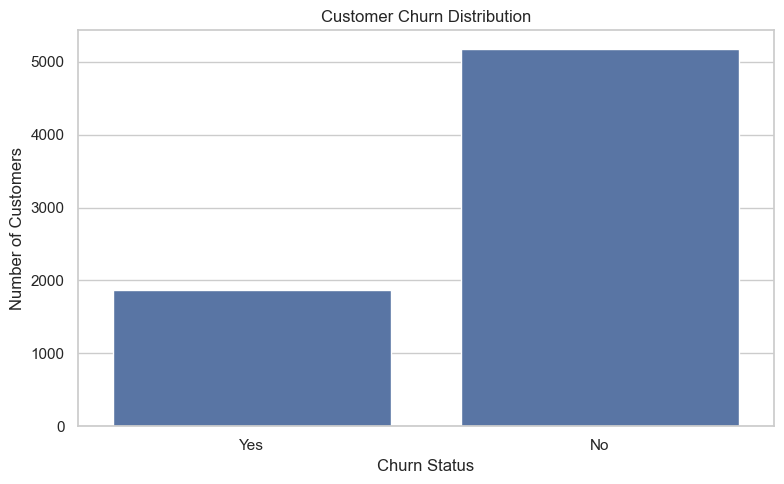

In [14]:
# ============================================================
# CELL 15: CHURN DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

# Create count plot.
sns.countplot(
    data=df,
    x="Churn Label"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.tight_layout()

# Save chart to the project visualization folder.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "01_churn_distribution.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

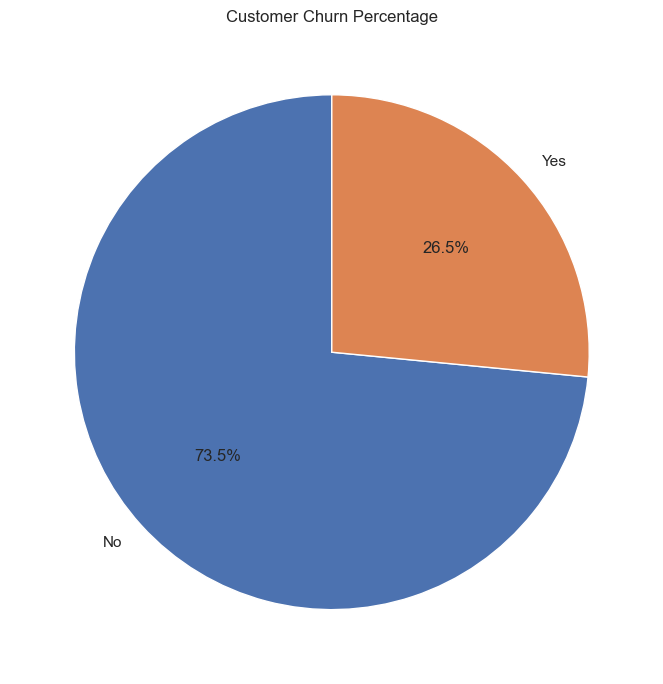

In [15]:
# ============================================================
# CELL 16: CHURN PERCENTAGE VISUALIZATION
# ============================================================

churn_counts = df["Churn Label"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.tight_layout()

# Save visualization.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "02_churn_percentage.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [16]:
# ============================================================
# CELL 17: IDENTIFY NUMERICAL FEATURES
# ============================================================

# Select numerical columns.
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("Numerical Columns:")

for column in numerical_columns:
    print("-", column)

Numerical Columns:
- Count
- Zip Code
- Latitude
- Longitude
- Tenure Months
- Monthly Charges
- Churn Value
- Churn Score
- CLTV


In [17]:
# ============================================================
# CELL 18: IDENTIFY CATEGORICAL FEATURES
# ============================================================

# Select categorical/object columns.
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("Categorical Columns:")

for column in categorical_columns:
    print("-", column)

Categorical Columns:
- CustomerID
- Country
- State
- City
- Lat Long
- Gender
- Senior Citizen
- Partner
- Dependents
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Total Charges
- Churn Label
- Churn Reason


In [18]:
# ============================================================
# CELL 19: GENDER VS CHURN
# ============================================================

# Calculate churn percentage by gender.
gender_churn = pd.crosstab(
    df["Gender"],
    df["Churn Label"],
    normalize="index"
) * 100

gender_churn = gender_churn.round(2)

gender_churn

Churn Label,No,Yes
Gender,,
Female,73.08,26.92
Male,73.84,26.16


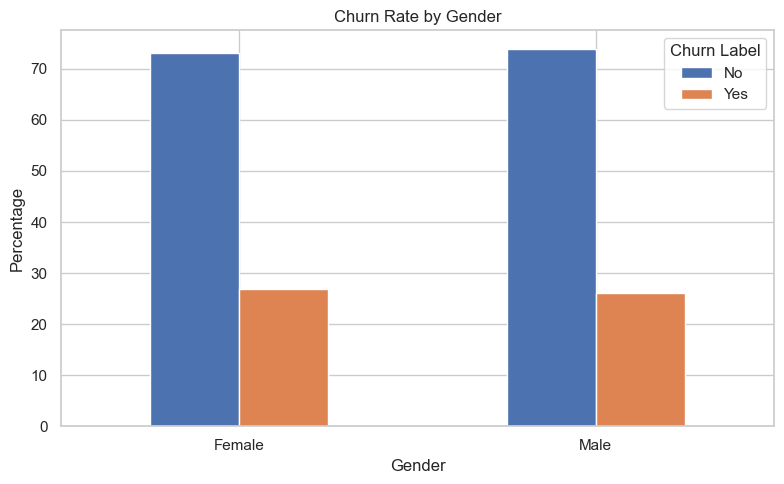

In [19]:
# ============================================================
# CELL 20: GENDER VS CHURN VISUALIZATION
# ============================================================

gender_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.tight_layout()

# Save visualization.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "03_gender_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [20]:
# ============================================================
# CELL 21: CONTRACT TYPE VS CHURN
# ============================================================

# Calculate churn percentage for each contract type.
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn = contract_churn.round(2)

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


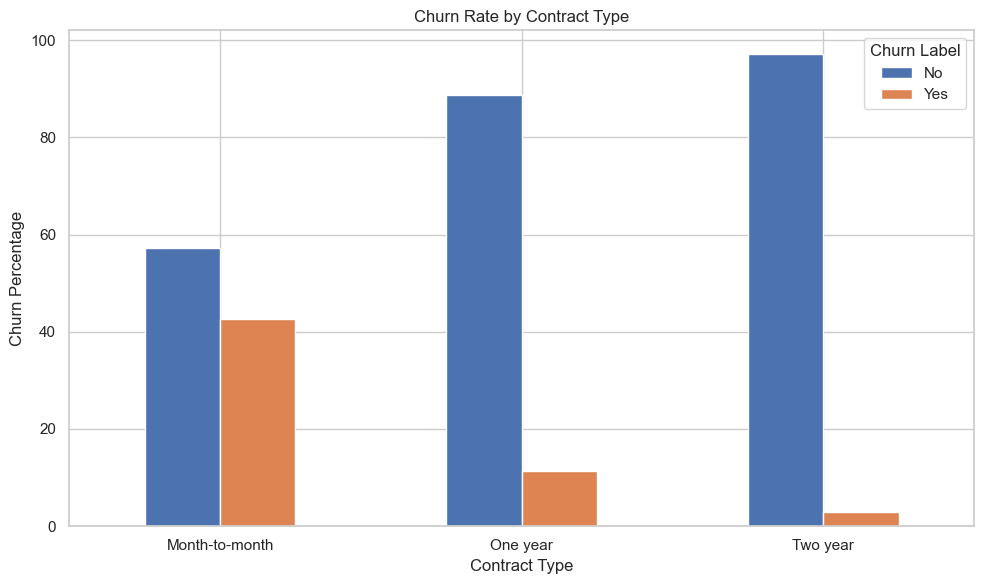

In [21]:
# ============================================================
# CELL 22: CONTRACT VS CHURN VISUALIZATION
# ============================================================

contract_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "04_contract_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [23]:
# ============================================================
# CELL 23: INTERNET SERVICE VS CHURN
# ============================================================

# Calculate churn percentage by internet service.
internet_churn = pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
) * 100

internet_churn = internet_churn.round(2)

internet_churn

Churn Label,No,Yes
Internet Service,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


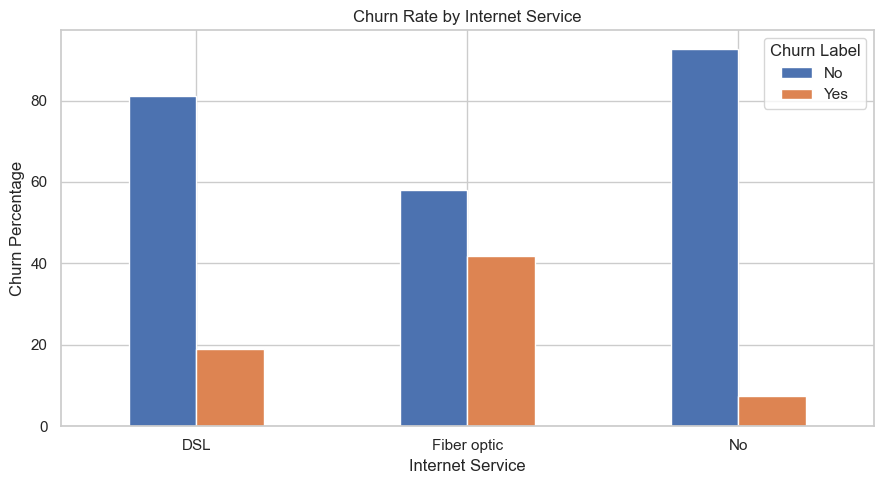

In [24]:
# ============================================================
# CELL 24: INTERNET SERVICE VS CHURN VISUALIZATION
# ============================================================

internet_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "05_internet_service_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [25]:
# ============================================================
# CELL 25: PAYMENT METHOD VS CHURN
# ============================================================

# Calculate churn percentage by payment method.
payment_churn = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
) * 100

payment_churn = payment_churn.round(2)

payment_churn

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


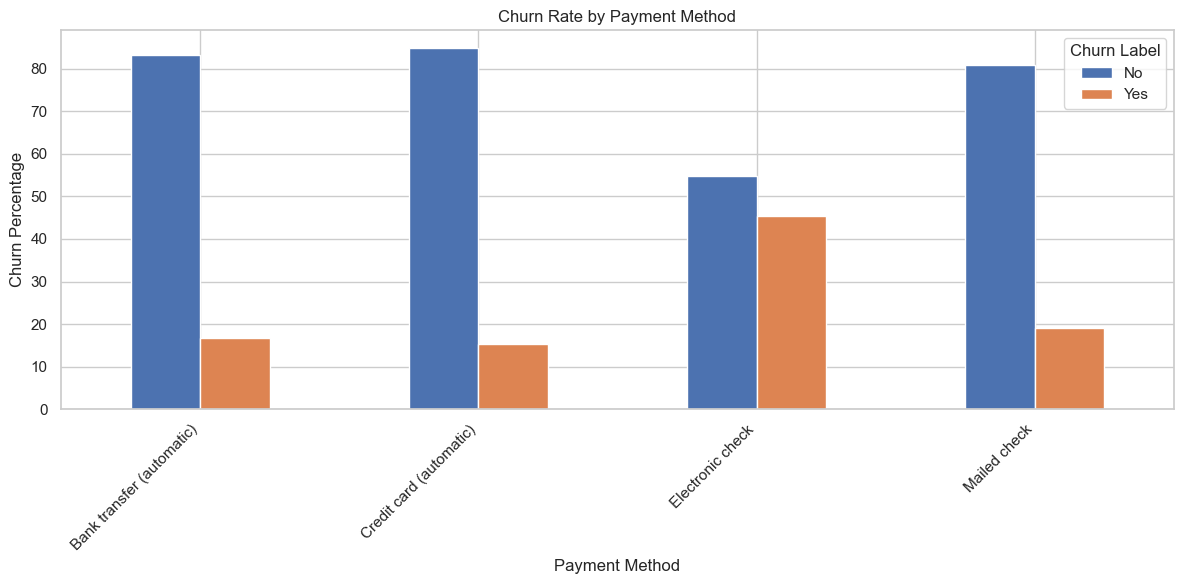

In [26]:
# ============================================================
# CELL 26: PAYMENT METHOD VS CHURN VISUALIZATION
# ============================================================

payment_churn.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Percentage")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "06_payment_method_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

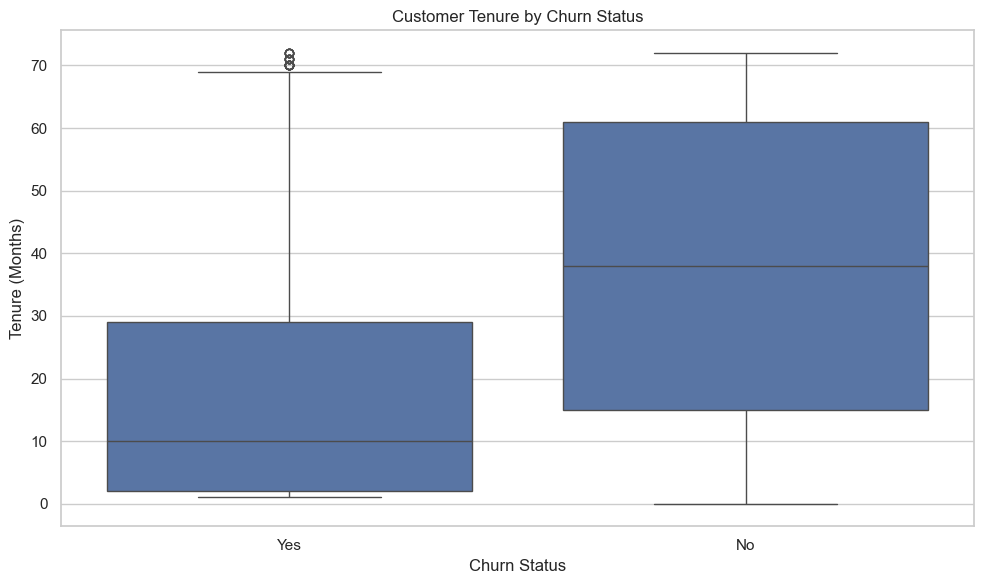

In [27]:
# ============================================================
# CELL 27: CUSTOMER TENURE VS CHURN
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Tenure (Months)")

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "07_tenure_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

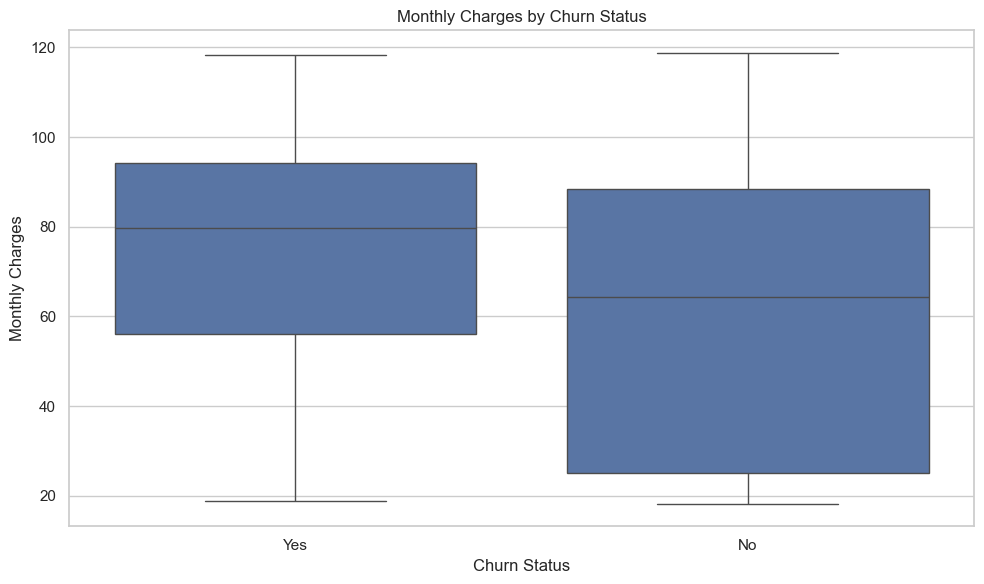

In [28]:
# ============================================================
# CELL 28: MONTHLY CHARGES VS CHURN
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Churn Label",
    y="Monthly Charges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "08_monthly_charges_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [29]:
# ============================================================
# CELL 29: SENIOR CITIZEN VS CHURN
# ============================================================

senior_churn = pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
) * 100

senior_churn = senior_churn.round(2)

senior_churn

Churn Label,No,Yes
Senior Citizen,,
No,76.39,23.61
Yes,58.32,41.68


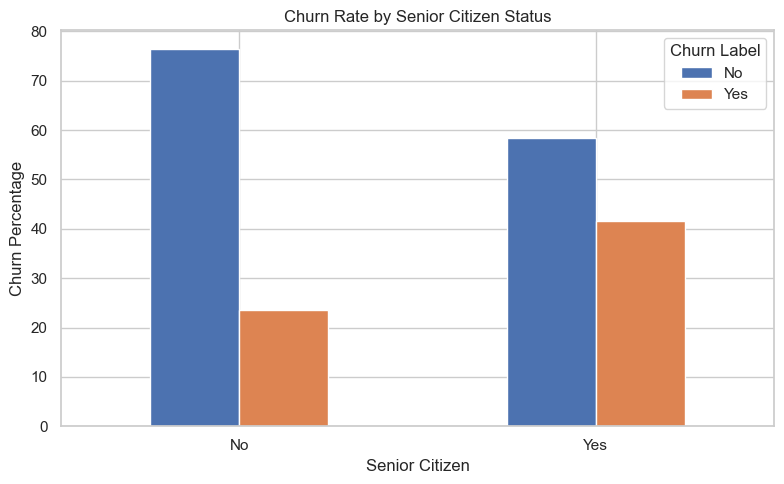

In [30]:
# ============================================================
# CELL 30: SENIOR CITIZEN VS CHURN VISUALIZATION
# ============================================================

senior_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "09_senior_citizen_vs_churn.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [31]:
# ============================================================
# CELL 31: PARTNER STATUS VS CHURN
# ============================================================

partner_churn = pd.crosstab(
    df["Partner"],
    df["Churn Label"],
    normalize="index"
) * 100

partner_churn = partner_churn.round(2)

partner_churn

Churn Label,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


In [32]:
# ============================================================
# CELL 32: DEPENDENTS VS CHURN
# ============================================================

dependents_churn = pd.crosstab(
    df["Dependents"],
    df["Churn Label"],
    normalize="index"
) * 100

dependents_churn = dependents_churn.round(2)

dependents_churn

Churn Label,No,Yes
Dependents,,
No,67.45,32.55
Yes,93.48,6.52


In [33]:
# ============================================================
# CELL 33: CONVERT TOTAL CHARGES TO NUMERIC
# ============================================================

# Total Charges may contain empty strings or text.
# Convert the column to numeric values.
# Invalid values will become NaN.

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

# Display data type after conversion.
print(
    "Total Charges Data Type:",
    df["Total Charges"].dtype
)

# Display number of missing values created.
print(
    "Missing Total Charges:",
    df["Total Charges"].isnull().sum()
)

Total Charges Data Type: float64
Missing Total Charges: 11


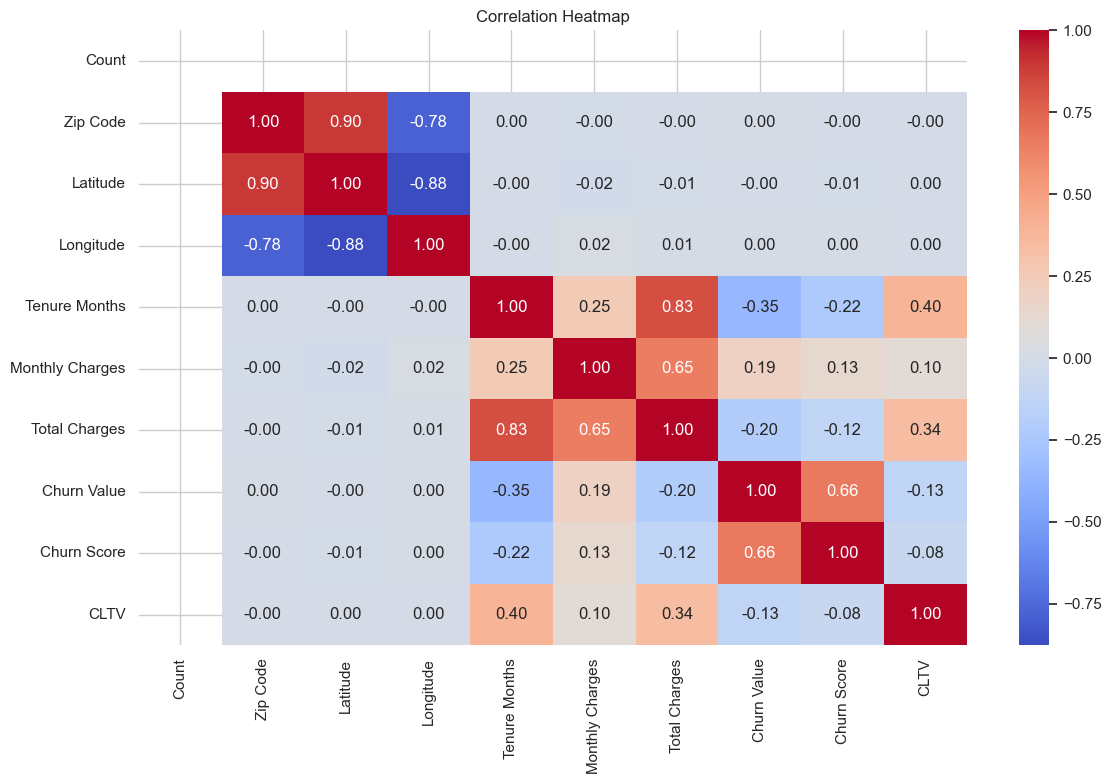

In [34]:
# ============================================================
# CELL 34: CORRELATION ANALYSIS
# ============================================================

# Select numerical columns.
numeric_for_corr = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_for_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "10_correlation_heatmap.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [35]:
# ============================================================
# CELL 35: PREPARE DATA FOR MACHINE LEARNING
# ============================================================

# Create a separate copy for machine learning.
ml_df = df.copy()

# Remove columns that should not be used as model features.
#
# These include:
# - Customer identifiers
# - Geographic identifiers
# - Post-outcome churn information
#
# Removing Churn Score, Churn Value and Churn Reason
# helps prevent target leakage.

columns_to_remove = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

ml_df = ml_df.drop(
    columns=columns_to_remove,
    errors="ignore"
)

print("Remaining Columns:")
print(list(ml_df.columns))

Remaining Columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label']


In [36]:
# ============================================================
# CELL 37: SEPARATE FEATURES AND TARGET
# ============================================================

# X contains input features.
X = ml_df.drop(
    columns=["Churn Label"]
)

# y contains the target variable.
y = ml_df["Churn Label"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (7043, 19)
Target Shape: (7043,)


In [37]:
# ============================================================
# CELL 38: IDENTIFY FEATURE TYPES
# ============================================================

# Identify numerical features.
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Identify categorical features.
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical Features:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [38]:
# ============================================================
# CELL 39: TRAIN-TEST SPLIT
# ============================================================

# Split the data into:
# 80% training data
# 20% testing data
#
# stratify=y maintains similar class proportions.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (5634, 19)
Testing Data: (1409, 19)


In [39]:
# ============================================================
# CELL 40: PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing:
# 1. Fill missing values with median.
# 2. Standardize numerical features.

numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# 1. Fill missing values with most frequent value.
# 2. Apply One-Hot Encoding.

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

# Combine numerical and categorical preprocessing.
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [40]:
# ============================================================
# CELL 41: LOGISTIC REGRESSION
# ============================================================

# Build Logistic Regression pipeline.
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model.
logistic_pipeline.fit(
    X_train,
    y_train
)

# Generate predictions.
logistic_pred = logistic_pipeline.predict(
    X_test
)

# Generate probability predictions.
logistic_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [41]:
# ============================================================
# CELL 42: DECISION TREE
# ============================================================

# Build Decision Tree pipeline.
decision_tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                max_depth=5
            )
        )
    ]
)

# Train the model.
decision_tree_pipeline.fit(
    X_train,
    y_train
)

# Generate predictions.
dt_pred = decision_tree_pipeline.predict(
    X_test
)

# Generate probability predictions.
dt_prob = decision_tree_pipeline.predict_proba(
    X_test
)[:, 1]

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [42]:
# ============================================================
# CELL 43: RANDOM FOREST
# ============================================================

# Build Random Forest pipeline.
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

# Train the model.
random_forest_pipeline.fit(
    X_train,
    y_train
)

# Generate predictions.
rf_pred = random_forest_pipeline.predict(
    X_test
)

# Generate probability predictions.
rf_prob = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [46]:
# ============================================================
# CELL 44: MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(name, y_true, y_pred, y_prob, pos_label="Yes"):
    """
    Calculate classification performance metrics.
    """
    # Convert string targets to binary integers (0/1) for ROC-AUC compatibility
    y_true_binary = (y_true == pos_label).astype(int)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(
            y_true, y_pred, pos_label=pos_label, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, pos_label=pos_label, zero_division=0
        ),
        "F1 Score": f1_score(
            y_true, y_pred, pos_label=pos_label, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_true_binary, y_prob),
    }

In [47]:
# ============================================================
# CELL 45: MODEL PERFORMANCE COMPARISON
# ============================================================

# Evaluate Logistic Regression.
logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

# Evaluate Decision Tree.
decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

# Evaluate Random Forest.
random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

# Combine all results into a DataFrame.
results = pd.DataFrame([
    logistic_results,
    decision_tree_results,
    random_forest_results
])

# Round metrics.
results = results.round(4)

# Display results.
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8020,0.6435,0.5695,0.6043,0.8487
1,Decision Tree,0.7942,0.6160,0.5963,0.6060,0.8357
2,Random Forest,0.7878,0.6271,0.4947,0.5531,0.8319


In [48]:
# ============================================================
# CELL 46: SAVE MODEL RESULTS
# ============================================================

# Define the output path for model results.
model_results_path = os.path.join(
    REPORT_PATH,
    "model_performance.csv"
)

# Save model comparison results.
results.to_csv(
    model_results_path,
    index=False
)

print("Model performance saved to:")
print(model_results_path)

Model performance saved to:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\reports\model_performance.csv


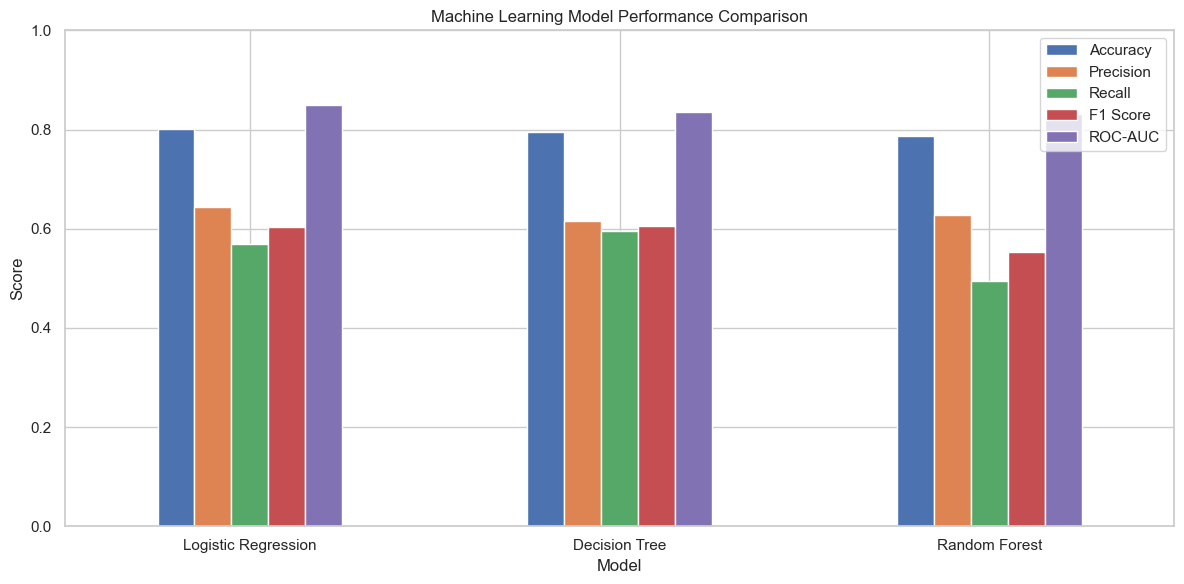

In [49]:
# ============================================================
# CELL 47: MODEL PERFORMANCE VISUALIZATION
# ============================================================

# Use model names as the index.
results_plot = results.set_index("Model")

# Create performance comparison chart.
results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Machine Learning Model Performance Comparison"
)

plt.xlabel("Model")
plt.ylabel("Score")

plt.xticks(rotation=0)

# Classification metrics range from 0 to 1.
plt.ylim(0, 1)

plt.tight_layout()

# Save chart.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "11_model_performance_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [50]:
# ============================================================
# CELL 48: RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

# Generate detailed classification report.
classification_report_text = classification_report(
    y_test,
    rf_pred,
    target_names=[
        "No Churn",
        "Churn"
    ],
    zero_division=0
)

print("Random Forest Classification Report")
print("=" * 55)
print(classification_report_text)

# Save classification report as a text file.
classification_report_path = os.path.join(
    REPORT_PATH,
    "classification_report.txt"
)

with open(
    classification_report_path,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "Random Forest Classification Report\n"
    )
    file.write("=" * 55 + "\n")
    file.write(classification_report_text)

print("\nClassification report saved to:")
print(classification_report_path)

Random Forest Classification Report
              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86      1035
       Churn       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


Classification report saved to:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\reports\classification_report.txt


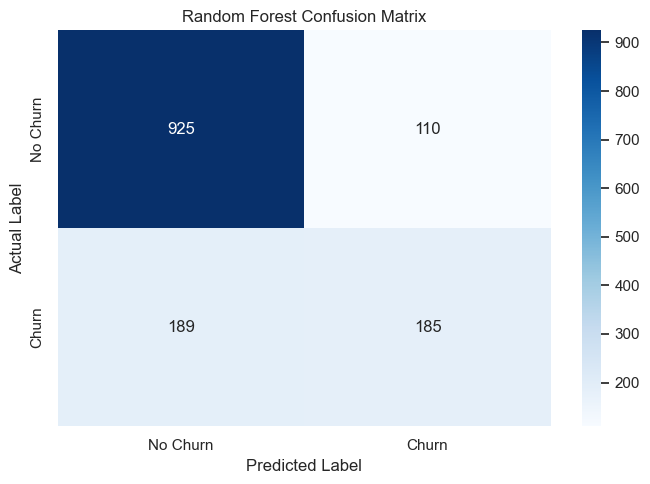

In [53]:
# ============================================================
# CELL 49: CONFUSION MATRIX
# ============================================================

# Calculate confusion matrix.
cm = confusion_matrix(
    y_test,
    rf_pred
)

# Create heatmap.
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "No Churn",
        "Churn"
    ],
    yticklabels=[
        "No Churn",
        "Churn"
    ]
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

# Save confusion matrix.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "12_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

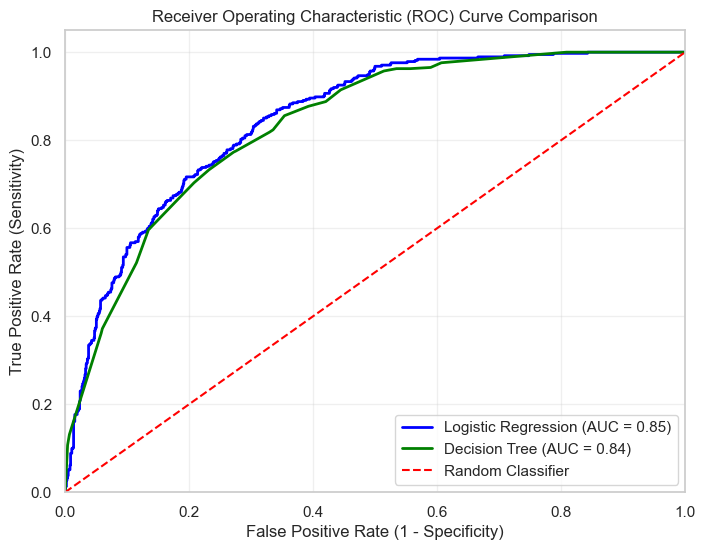

In [55]:
# ============================================================
# CELL 50: ROC CURVE COMPARISON
# ============================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get predicted probabilities for the positive class ('Yes')
# (Ensure model.predict_proba(X_test)[:, 1] was used when defining these)
# logistic_prob = model_lr.predict_proba(X_test)[:, 1]
# dt_prob = model_dt.predict_proba(X_test)[:, 1]

# 2. Calculate ROC curve values using pos_label='Yes'
fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_test,
    logistic_prob,
    pos_label='Yes'
)

fpr_dt, tpr_dt, thresholds_dt = roc_curve(
    y_test,
    dt_prob,
    pos_label='Yes'
)

# 3. Calculate Area Under Curve (AUC) scores
roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_dt = auc(fpr_dt, tpr_dt)

# 4. Plot ROC Curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr, tpr_lr, 
    color='blue', lw=2, 
    label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})'
)
plt.plot(
    fpr_dt, tpr_dt, 
    color='green', lw=2, 
    label=f'Decision Tree (AUC = {roc_auc_dt:.2f})'
)

# Baseline random chance line (50%)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=1.5, label='Random Classifier')

# Formatting plot details
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.show()

In [56]:
# ============================================================
# CELL 51: RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

# Get feature names after preprocessing.
feature_names = (
    random_forest_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get Random Forest feature importance values.
feature_importances = (
    random_forest_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

# Create feature importance DataFrame.
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

# Sort features from highest to lowest importance.
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Select top 15 features.
top_features = importance_df.head(15)

# Display top features.
top_features

,Feature,Importance
2,num__Total Charges,0.133851
0,num__Tenure Months,0.125946
1,num__Monthly Charges,0.116924
37,cat__Contract_Month-to-month,0.068586
39,cat__Contract_Two year,0.035604
19,cat__Online Security_No,0.034955
28,cat__Tech Support_No,0.030431
10,cat__Dependents_Yes,0.028837
44,cat__Payment Method_Electronic check,0.027464
9,cat__Dependents_No,0.026471


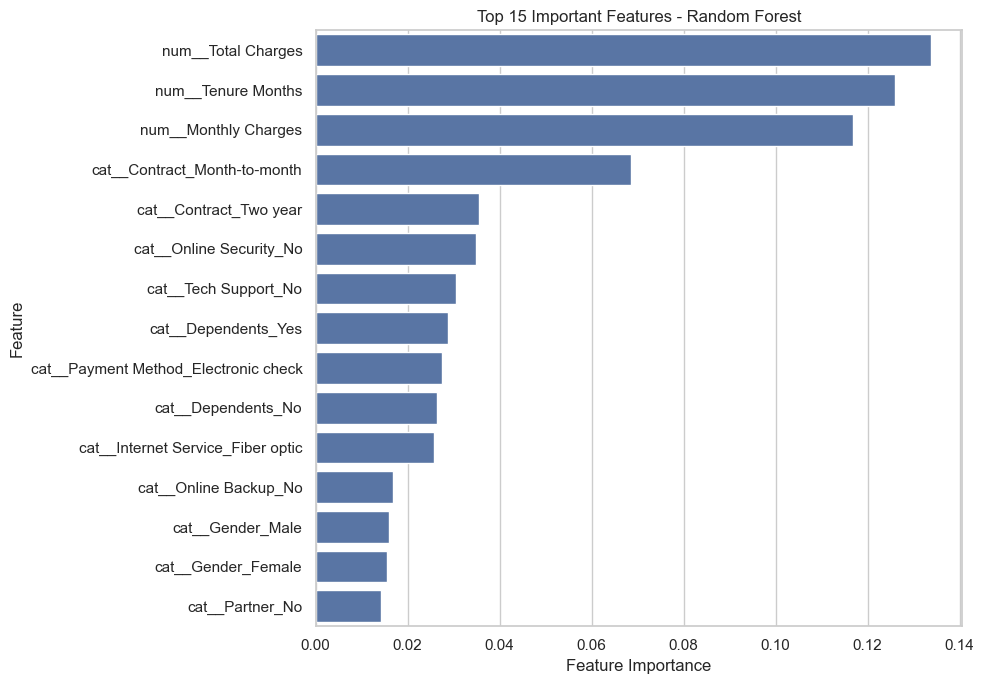

In [57]:
# ============================================================
# CELL 52: FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Important Features - Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

# Save feature importance chart.
plt.savefig(
    os.path.join(
        VISUALIZATION_PATH,
        "14_feature_importance.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [58]:
# ============================================================
# CELL 53: IDENTIFY BEST MODEL
# ============================================================

# Find the model with the highest ROC-AUC score.
best_model_row = results.loc[
    results["ROC-AUC"].idxmax()
]

best_model_name = best_model_row["Model"]
best_accuracy = best_model_row["Accuracy"]
best_precision = best_model_row["Precision"]
best_recall = best_model_row["Recall"]
best_f1 = best_model_row["F1 Score"]
best_auc = best_model_row["ROC-AUC"]

print("Best Model:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))
print("F1 Score:", round(best_f1, 4))
print("ROC-AUC:", round(best_auc, 4))

Best Model: Logistic Regression
Accuracy: 0.802
Precision: 0.6435
Recall: 0.5695
F1 Score: 0.6043
ROC-AUC: 0.8487


In [59]:
# ============================================================
# CELL 54: TOP FEATURES SUMMARY
# ============================================================

# Display the top 15 features influencing
# Random Forest predictions.

top_features.reset_index(
    drop=True
)

,Feature,Importance
0,num__Total Charges,0.133851
1,num__Tenure Months,0.125946
2,num__Monthly Charges,0.116924
3,cat__Contract_Month-to-month,0.068586
4,cat__Contract_Two year,0.035604
5,cat__Online Security_No,0.034955
6,cat__Tech Support_No,0.030431
7,cat__Dependents_Yes,0.028837
8,cat__Payment Method_Electronic check,0.027464
9,cat__Dependents_No,0.026471


# 9. Key Business Insights

The analysis of 7,043 customer records identified several important
patterns related to customer churn.

### 1. Overall Churn

The overall customer churn rate is **26.54%**, indicating that more
than one-fourth of the customers in the dataset have discontinued
their services. This represents a significant customer retention
challenge.

### 2. Important Customer Characteristics

The feature importance analysis identified **Total Charges,
Tenure Months, and Monthly Charges** as the three most influential
numerical features in the Random Forest analysis.

### 3. Contract Type

Contract-related features were among the most important predictors.
In particular, the **Month-to-month contract** feature had a relatively
high importance, indicating that contract structure is strongly
associated with customer churn behavior.

### 4. Service-Related Factors

Features related to **Online Security, Tech Support, Online Backup,
and Internet Service** were also identified among the important
predictors. This indicates that the services subscribed to by a
customer may contribute to differences in churn behavior.

### 5. Payment Method

**Electronic check** was identified as an important feature in the
model, suggesting that payment method is associated with customer
churn patterns.

### 6. Machine Learning Performance

Three classification models were evaluated. Logistic Regression
achieved the strongest overall performance based on ROC-AUC.

The Logistic Regression model achieved:

- Accuracy: **80.20%**
- Precision: **64.35%**
- Recall: **56.95%**
- F1 Score: **60.43%**
- ROC-AUC: **84.87%**

The ROC-AUC score of **0.8487** indicates that the model has good
ability to distinguish between customers who churn and customers
who remain.

# 10. Business Recommendations

Based on the exploratory analysis and machine learning results,
the following recommendations can be made.

### 1. Focus on Month-to-Month Customers

Customers with month-to-month contracts should be considered a
priority segment for retention campaigns.

The company can encourage these customers to move toward longer-term
contracts by offering loyalty benefits, discounts, or additional
service advantages.

### 2. Strengthen Early Customer Engagement

Tenure was one of the most important predictive features.

The company should therefore focus on the early stages of the
customer lifecycle through better onboarding, customer support,
and regular engagement.

### 3. Monitor High Monthly-Charge Customers

Monthly Charges was one of the top predictive features.

Customers with comparatively high monthly charges should be analyzed
to determine whether pricing, service packages, or perceived value
are contributing to churn.

### 4. Improve Online Security and Technical Support

Online Security and Tech Support appeared among the important
predictive features.

The company should evaluate whether customers without these services
have different retention patterns and consider targeted service
bundles or promotional offers.

### 5. Monitor Electronic Check Customers

Electronic check payment was identified as an important predictor.

The company can investigate this customer segment further and
consider encouraging alternative convenient payment methods where
appropriate.

### 6. Use Predictive Churn Scoring

The Logistic Regression model achieved an ROC-AUC of **84.87%**.

The model can therefore be used as a decision-support tool to
identify customers with higher churn probability and prioritize
retention efforts.

### 7. Develop Personalized Retention Strategies

Instead of using the same retention strategy for every customer,
the business can segment customers according to contract type,
tenure, charges, services, and predicted churn risk.

# 11. Limitations

- The analysis is based on historical customer data.
- The model cannot guarantee that a customer will actually churn.
- The dataset may not contain every factor influencing customer
  decisions.
- External factors such as competitor pricing, economic conditions,
  and customer satisfaction are not fully represented.
- Model performance depends on the quality and completeness of
  the available dataset.
- The feature importance results describe predictive relationships
  and should not automatically be interpreted as causal relationships.
- Additional validation would be required before deploying the
  model in a production business environment.

# 12. Future Scope

The project can be extended in several ways.

### 1. Model Deployment

Deploy the churn prediction model as a web application using
Flask or FastAPI.

### 2. Interactive Dashboard

Develop an interactive dashboard using Power BI, Tableau, or
a Python-based dashboard framework.

### 3. Advanced Machine Learning

Experiment with advanced algorithms such as:

- XGBoost
- Gradient Boosting
- LightGBM
- Support Vector Machines

### 4. Real-Time Churn Prediction

Integrate the model with customer management systems to generate
real-time churn risk predictions.

### 5. Automated Retention Alerts

Create an automated system that alerts customer service teams
when a customer reaches a high predicted churn probability.

### 6. Customer Segmentation

Combine churn prediction with customer segmentation to develop
personalized retention strategies.

### 7. Additional Data Sources

Future versions can incorporate:

- Customer feedback
- Support tickets
- Service complaints
- Usage behavior
- Customer satisfaction scores
- Marketing interaction data

# 13. Conclusion

This project successfully demonstrated a complete Data Science
workflow for customer churn prediction and business analytics.

The analysis was performed on **7,043 customer records** and included
data understanding, data quality analysis, data cleaning,
exploratory data analysis, visualization, feature preparation,
machine learning, model evaluation, and business interpretation.

The overall customer churn rate was **26.54%**, demonstrating a
significant customer retention challenge.

Three machine learning classification algorithms were evaluated:
Logistic Regression, Decision Tree, and Random Forest.

Among the evaluated models, **Logistic Regression** achieved the
best overall performance with an accuracy of **80.20%** and an
ROC-AUC score of **84.87%**. The model also achieved a precision of
**64.35%**, recall of **56.95%**, and F1 score of **60.43%**.

The feature analysis identified Total Charges, Tenure Months,
Monthly Charges, contract type, Online Security, Tech Support,
Dependents, payment method, and Internet Service as important
predictive factors.

These findings can help businesses identify customers who are more
likely to churn and develop targeted retention strategies.

Overall, the project demonstrates how Data Science and Machine
Learning can transform customer data into actionable business
insights and support data-driven customer retention decisions.

In [60]:
# ============================================================
# CELL 60: SAVE FINAL PROJECT SUMMARY
# ============================================================

# Create a summary dictionary containing the main project metrics.
project_summary = {
    "Total Customers": len(df),
    "Total Features": df.shape[1],
    "Churned Customers": int(
        (df["Churn Label"] == "Yes").sum()
    ),
    "Retained Customers": int(
        (df["Churn Label"] == "No").sum()
    ),
    "Overall Churn Rate (%)": round(
        (df["Churn Label"] == "Yes").mean() * 100,
        2
    ),
    "Best Model": best_model_name,
    "Best Accuracy": round(best_accuracy, 4),
    "Best Precision": round(best_precision, 4),
    "Best Recall": round(best_recall, 4),
    "Best F1 Score": round(best_f1, 4),
    "Best ROC-AUC": round(best_auc, 4)
}

# Convert summary into a DataFrame.
summary_df = pd.DataFrame(
    list(project_summary.items()),
    columns=["Metric", "Value"]
)

# Save summary.
summary_path = os.path.join(
    REPORT_PATH,
    "final_project_summary.csv"
)

summary_df.to_csv(
    summary_path,
    index=False
)

print("Final project summary saved to:")
print(summary_path)

display(summary_df)

Final project summary saved to:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\reports\final_project_summary.csv


,Metric,Value
0,Total Customers,7043
1,Total Features,33
2,Churned Customers,1869
3,Retained Customers,5174
4,Overall Churn Rate (%),26.54
5,Best Model,Logistic Regression
6,Best Accuracy,0.802
7,Best Precision,0.6435
8,Best Recall,0.5695
9,Best F1 Score,0.6043


In [61]:
# ============================================================
# CELL 61: VERIFY GENERATED OUTPUT FILES
# ============================================================

print("Generated Visualization Files:")
print("=" * 50)

for file_name in sorted(
    os.listdir(VISUALIZATION_PATH)
):
    print(file_name)

print("\nGenerated Report Files:")
print("=" * 50)

for file_name in sorted(
    os.listdir(REPORT_PATH)
):
    print(file_name)

Generated Visualization Files:
01_churn_distribution.png
02_churn_percentage.png
03_gender_vs_churn.png
04_contract_vs_churn.png
05_internet_service_vs_churn.png
06_payment_method_vs_churn.png
07_tenure_vs_churn.png
08_monthly_charges_vs_churn.png
09_senior_citizen_vs_churn.png
10_correlation_heatmap.png
11_model_performance_comparison.png
12_confusion_matrix.png
14_feature_importance.png

Generated Report Files:
classification_report.txt
final_project_summary.csv
model_performance.csv


In [62]:
# ============================================================
# CELL 62: FINAL PROJECT STATUS
# ============================================================

print("=" * 60)
print("FINAL DATA SCIENCE CAPSTONE PROJECT")
print("=" * 60)

print("\nProject: Customer Churn Prediction and Business Analytics")

print("\nDataset:")
print(DATA_PATH)

print("\nTotal Customers:", len(df))
print("Total Columns:", df.shape[1])

print(
    "\nOverall Churn Rate:",
    round(
        (df["Churn Label"] == "Yes").mean() * 100,
        2
    ),
    "%"
)

print("\nBest Model:", best_model_name)
print("Accuracy:", round(best_accuracy, 4))
print("Precision:", round(best_precision, 4))
print("Recall:", round(best_recall, 4))
print("F1 Score:", round(best_f1, 4))
print("ROC-AUC:", round(best_auc, 4))

print("\nVisualization Folder:")
print(VISUALIZATION_PATH)

print("\nReport Folder:")
print(REPORT_PATH)

print("\nProject analysis completed successfully.")

FINAL DATA SCIENCE CAPSTONE PROJECT

Project: Customer Churn Prediction and Business Analytics

Dataset:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\data\raw\Telco_customer_churn.xlsx

Total Customers: 7043
Total Columns: 33

Overall Churn Rate: 26.54 %

Best Model: Logistic Regression
Accuracy: 0.802
Precision: 0.6435
Recall: 0.5695
F1 Score: 0.6043
ROC-AUC: 0.8487

Visualization Folder:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\visualizations

Report Folder:
C:\Users\Yash\OneDrive\Desktop\AI-ML-Research-Specialist-Internship\Task-06-Final-Data-Science-Capstone\reports

Project analysis completed successfully.
